# 🐶🐱 Dog vs Cat Image Classifier

This project uses a CNN model to classify images of dogs and cats.

Dataset: Kaggle Dogs vs Cats

In [1]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"prasanshabairagi","key":"af6bb73a88b65810f9dbafc8511f3ac1"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv "kaggle (2).json" kaggle.json
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:04<00:00, 202MB/s]



In [5]:
!ls

dog-and-cat-classification-dataset.zip	kaggle.json  sample_data


In [6]:
!unzip '/content/dog-and-cat-classification-dataset.zip' -d '/content/dataset'

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/PetImages/Dog/5499.jpg  
  inflating: /content/dataset/PetImages/Dog/55.jpg  
  inflating: /content/dataset/PetImages/Dog/550.jpg  
  inflating: /content/dataset/PetImages/Dog/5500.jpg  
  inflating: /content/dataset/PetImages/Dog/5501.jpg  
  inflating: /content/dataset/PetImages/Dog/5502.jpg  
  inflating: /content/dataset/PetImages/Dog/5503.jpg  
  inflating: /content/dataset/PetImages/Dog/5504.jpg  
  inflating: /content/dataset/PetImages/Dog/5505.jpg  
  inflating: /content/dataset/PetImages/Dog/5506.jpg  
  inflating: /content/dataset/PetImages/Dog/5507.jpg  
  inflating: /content/dataset/PetImages/Dog/5508.jpg  
  inflating: /content/dataset/PetImages/Dog/5509.jpg  
  inflating: /content/dataset/PetImages/Dog/551.jpg  
  inflating: /content/dataset/PetImages/Dog/5510.jpg  
  inflating: /content/dataset/PetImages/Dog/5511.jpg  
  inflating: /content/dataset/PetImages/Dog/5512.jpg  
  inflating: /cont

In [7]:
!ls /content/dataset

PetImages


In [8]:
import os
from PIL import Image

def remove_corrupt_images(folder):
    for class_name in ['Cat', 'Dog']:
        class_path = os.path.join(folder, class_name)
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            try:
                with Image.open(img_path) as image:
                    image.verify()
            except:
                print(f'Removing corrupted image: {img_path}')
                os.remove(img_path)

remove_corrupt_images('/content/dataset/PetImages')
print('Corrupted images removed ....')

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed ....


In [13]:
!ls /content/dataset/PetImages

Cat  Dog


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


data_gen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.20,
    horizontal_flip=True,
    zoom_range=0.2
)


train_generator = data_gen.flow_from_directory(
    '/content/dataset/PetImages',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


validation_generator = data_gen.flow_from_directory(
    '/content/dataset/PetImages',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [17]:

import os
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout


def remove_corrupt_images(folder):
    for class_name in ['Cat', 'Dog']:
        class_path = os.path.join(folder, class_name)
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            try:
                with Image.open(img_path) as image:
                    image.verify()
            except:
                print(f'Removing corrupted image: {img_path}')
                os.remove(img_path)

remove_corrupt_images('/content/dataset/PetImages')
print("Corrupted images removed ...")


data_gen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_generator = data_gen.flow_from_directory(
    '/content/dataset/PetImages',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = data_gen.flow_from_directory(
    '/content/dataset/PetImages',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


model = Sequential()
# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPool2D(2,2))
# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Flatten())
# Dense
model.add(Dense(128, activation='relu'))
# Output
model.add(Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Corrupted images removed ...
Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 825s 1s/step - accuracy: 0.6535 - loss: 0.6161 - val_accuracy: 0.7159 - val_loss: 0.5484
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.7541 - loss: 0.5060 - val_accuracy: 0.7753 - val_loss: 0.4698
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 800s 1s/step - accuracy: 0.7851 - loss: 0.4544 - val_accuracy: 0.8045 - val_loss: 0.4147
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.8120 - loss: 0.4105 - val_accuracy: 0.8217 - val_loss: 0.3909
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.8245 - loss: 0.3880 - val_accuracy: 0.8031 - val_loss: 0.4495


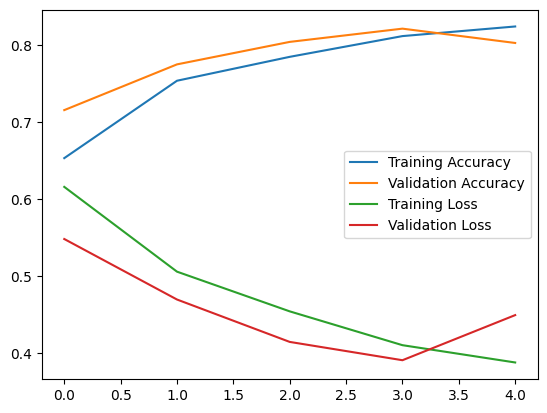

In [18]:
import matplotlib.pyplot as plt

# Plot training accuracy and loss
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [19]:
# Example: pick an image from the training dataset
img_path = '/content/dataset/PetImages/Dog/9930.jpg'   # replace 123.jpg with actual filename

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
It is a dog


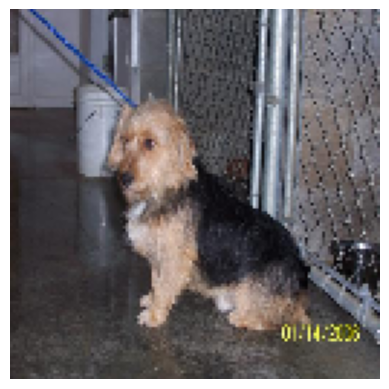

In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)  # (1,128,128,3)

pred = model.predict(img_array)

plt.imshow(img)
plt.axis('off')

if pred[0][0] > 0.5:
    print('It is a dog')
else:
    print('It is a cat')